<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">

---
---

# 06: The Variant Architect
### Variant Effect Prediction with DNA Foundation Models

In Notebooks 03–05, **Dr. Aris** trained DNA language models to classify promoters. But the same pretrained representations can answer a deeper and more clinically urgent question: **when a single base in a patient's genome differs from the reference, does it matter?**

This is **variant effect prediction (VEP)** — estimating the functional impact of a genetic mutation. It is one of the most direct clinical applications of DNA foundation models, used every day in clinical genetics labs to prioritize the thousands of variants found in a patient's exome and identify the handful that might be causing disease.

We don't need additional training. Using the classifier checkpoints from NB03–NB05 as zero-shot scorers, we implement **In Silico Mutagenesis (ISM)** — systematically mutating every position in a reference sequence and measuring how each model's promoter confidence changes.

---
### 🎯 Learning Objectives
1. **VEP as zero-shot scoring** — understand how pretrained models score mutations without labeled variants
2. **The ISM framework** — implement systematic single-nucleotide scanning
3. **Tokenization resolution** — see concretely why single-nucleotide models detect SNPs more precisely
4. **ISM heatmaps** — interpret position × base sensitivity maps
5. **Clinical framing** — connect model scores to real variant classification workflows

### 📚 What We'll Build
1. **ISM engine** — mutate every position to every alternative base, score each
2. **Sensitivity heatmaps** — full position × base effect matrix per model
3. **Tokenization blurring demo** — quantify how k-mer models smear SNP signals
4. **Pathogenic vs benign separation** — validate the approach on controlled synthetic variants

### 📐 Series Position

| NB | Core topic | Clinical link |
|---|---|---|
| NB03 | Transformer DNA models | Baseline representations |
| NB04 | Mamba / Caduceus | Long-range regulatory modeling |
| NB05 | Hyena / HyenaDNA | SNP-resolution context |
| **NB06** | **Variant Effect Prediction** | **Patient variant interpretation** |
| NB07 | Fine-tuning strategies | Improving VEP calibration |

## 0. Environment Setup

> **NB06 runs on CPU deliberately.** The GPU is shared across all notebook kernels on HiPerGator. VEP scoring on 57 bp sequences is fast enough on CPU (~1–2 ms per forward pass), and running on CPU avoids competing with other kernels for VRAM. If you see OOM errors, shut down the NB04 and NB05 kernels first.

In [1]:
# !pip install torch transformers datasets scikit-learn matplotlib seaborn requests

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, AutoConfig
from tqdm.auto import tqdm
import warnings, requests, json, os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("✅ Imports successful")

✅ Imports successful


## 1. Hardware Detection

VEP requires many forward passes — a full ISM scan of a 57 bp sequence is 57 positions × 3 alternative bases = **171 forward passes per model**. This is fast on CPU (~1 second per model) but benefits from GPU for longer sequences.

This notebook deliberately uses CPU to avoid VRAM conflicts with other kernels in the series.

In [2]:
# NB06 uses CPU deliberately — the GPU is shared across notebooks on HiPerGator
# and may already be near capacity from NB03-NB05 model weights.
# VEP scoring on 57 bp sequences is fast on CPU: ~1-2 ms per forward pass.

if torch.cuda.is_available():
    free_gb = torch.cuda.mem_get_info()[0] / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU available: {torch.cuda.get_device_name(0)} ({free_gb:.1f}/{total_gb:.0f} GB free)")

# Use CPU to avoid competing with other notebook kernels for VRAM
device = torch.device('cpu')
print(f"\n✅ Using device: {device}")
print("   (CPU chosen deliberately — avoids OOM when GPU is shared)")

torch.manual_seed(42)
np.random.seed(42)

GPU available: NVIDIA L4 (10.0/24 GB free)

✅ Using device: cpu
   (CPU chosen deliberately — avoids OOM when GPU is shared)


## 2. Variant Effect Prediction: The Framework

*"A DNA foundation model trained on the human genome learns what 'normal' DNA looks like. When we show it a mutated sequence, its confidence drops if the mutation breaks a pattern the model learned during pretraining. The size of that drop is our effect score — large drops suggest the mutation is disrupting something functionally important."* — Dr. Aris

### The Three VEP Approaches

| Method | Mechanism | Fine-tuning required? |
|---|---|---|
| **Zero-shot classifier ISM** | Compare classifier scores on WT vs mutant | No (uses existing checkpoints) |
| **Masked token probability** | For MLM models: compare log P(WT base) vs log P(mut base) | No |
| **Supervised VEP** | Fine-tune on labeled pathogenic/benign variants | Yes |

We use **ISM with our fine-tuned classifiers** from NB03–NB05. This is zero-shot with respect to variant labels — we never showed any model a labeled variant.

### The ISM Algorithm

```python
for position i in range(len(sequence)):
    for alternative_base in {A,T,C,G} - {reference_base[i]}:
        mutant = sequence[:i] + alternative_base + sequence[i+1:]
        effect[i, alternative_base] = score(wildtype) - score(mutant)
        # Positive = mutation reduces promoter score (predicted deleterious)
```

### Why Tokenization Changes Everything for SNP Scoring

A single base change at position $i$ affects:
- **Single-nucleotide models (NT, HyenaDNA):** exactly 1 token — clean, localized signal
- **6-mer DNABERT:** up to 6 overlapping windows — signal smears across 6 positions
- **BPE DNABERT-2:** 1–3 tokens depending on boundary location

Single-nucleotide models produce ISM maps where each spike corresponds to exactly one causal base. This is not just aesthetically cleaner — it is clinically correct. In a real VEP workflow, knowing that position 34 causes the effect is more actionable than knowing that positions 31–36 are collectively affected.

## 3. Reference Sequences

We work with three sequences derived from the UCI Promoter dataset:

1. **Wild-type promoter** — a real functional promoter containing a canonical TATA box
2. **TATA box mutant** — the same promoter with `TATAAA → GCGCGC` (destroys the core promoter signal)
3. **Silent mutant** — a single base change in a non-functional region

**Why these three?** They form a positive control:
- A well-calibrated VEP model should score the TATA box mutation much higher than the silent mutation
- The TATA box is one of the best-characterized pathogenic promoter elements in human genetics
- If a model doesn't detect this, it hasn't learned promoter biology

The cell scans all promoters in the dataset for canonical TATA motifs and selects the first sequence with a confirmed match — ensuring the downstream analysis has a real signal to find.

In [3]:
print('📥 Loading UCI Promoter dataset...')
url = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/'
    'molecular-biology/promoter-gene-sequences/promoters.data'
)
response = requests.get(url, timeout=30)
lines = [l.strip().split(',') for l in response.text.strip().split('\n') if l.strip()]
rows = [
    {'sequence': l[2].replace('\t','').replace(' ','').upper(),
     'label': 1 if l[0].strip() == '+' else 0}
    for l in lines
]
promoter_df = pd.DataFrame(rows)
positives   = promoter_df[promoter_df['label'] == 1].reset_index(drop=True)

# Pick the first positive sequence that contains a canonical TATA box
# TATA boxes appear as TATAAA, TATATAA, TATATA or similar — try several motifs
TATA_MOTIFS = ['TATAAA', 'TATATA', 'TATATAT', 'TATATAA']
wt_seq   = None
tata_pos = -1
tata_motif_found = ''

for _, row in positives.iterrows():
    seq = row['sequence']
    for motif in TATA_MOTIFS:
        pos = seq.find(motif)
        if pos >= 0:
            wt_seq          = seq
            tata_pos        = pos
            tata_motif_found = motif
            break
    if wt_seq: break

# If still not found, use the first positive and mark the highest-sensitivity
# region manually (will be updated after ISM runs)
if wt_seq is None:
    wt_seq   = positives.iloc[0]['sequence']
    tata_pos = -1
    print("⚠️  No canonical TATA box found — will use ISM peak position instead")

# TATA box mutant — substitute the motif with GCGCGC
motif_len = len(tata_motif_found) if tata_motif_found else 6
if tata_pos >= 0:
    tata_mutant = wt_seq[:tata_pos] + 'GCGCGC' + wt_seq[tata_pos + motif_len:]
    # Pad/trim to keep same length as wt_seq
    if len(tata_mutant) < len(wt_seq):
        tata_mutant = tata_mutant + wt_seq[len(tata_mutant):]
    tata_mutant = tata_mutant[:len(wt_seq)]
else:
    tata_mutant = wt_seq  # placeholder; will be updated after ISM

# Silent mutant — change a base in the middle of the sequence (away from TATA)
silent_pos = 5 if tata_pos > 10 else len(wt_seq) - 6
alt_base   = 'C' if wt_seq[silent_pos] != 'C' else 'G'
silent_mutant = wt_seq[:silent_pos] + alt_base + wt_seq[silent_pos+1:]

print(f"✅ Loaded {len(promoter_df)} sequences ({len(positives)} promoters)")
print(f"\n📍 Wild-type sequence ({len(wt_seq)} bp):")
print(f"   {wt_seq}")
if tata_pos >= 0:
    print(f"\n🔴 TATA box: motif '{tata_motif_found}' at position {tata_pos}")
else:
    print("\n⚠️  TATA box: not found by motif search — will use ISM peak")
print(f"\n🧬 Three sequences for VEP analysis:")
print(f"   WT:          {wt_seq}")
print(f"   TATA mutant: {tata_mutant}")
print(f"   Silent mut:  {silent_mutant}  ← position {silent_pos} only")


📥 Loading UCI Promoter dataset...
✅ Loaded 106 sequences (53 promoters)

📍 Wild-type sequence (57 bp):
   AGGGGCAAGGAGGATGGAAAGAGGTTGCCGTATAAAGAAACTAGAGTCCGTTTAGGT

🔴 TATA box: motif 'TATAAA' at position 30

🧬 Three sequences for VEP analysis:
   WT:          AGGGGCAAGGAGGATGGAAAGAGGTTGCCGTATAAAGAAACTAGAGTCCGTTTAGGT
   TATA mutant: AGGGGCAAGGAGGATGGAAAGAGGTTGCCGGCGCGCGAAACTAGAGTCCGTTTAGGT
   Silent mut:  AGGGGGAAGGAGGATGGAAAGAGGTTGCCGTATAAAGAAACTAGAGTCCGTTTAGGT  ← position 5 only


## 4. Load Fine-tuned Models from the Series

We reload the classifier checkpoints saved in NB03–NB05. No additional training needed — we use these models purely as scorers.

**Checkpoint files required** (must be in the working directory where NB03–NB05 were run):
- `dnabert_best.pt` — DNABERT classifier from NB03
- `hyena_pretrained_best.pt` — HyenaDNA classifier from NB05

> **Note:** HyenaDNA's backbone rejects `attention_mask` as a forward argument — the same fix applied in NB05 is applied here. The mask is built manually from the pad token ID and used only for masked mean pooling.

In [4]:
# ── DNABERT ───────────────────────────────────────────────────────────────────
DNABERT_NAME = 'zhihan1996/DNA_bert_6'
print("🧬 Loading DNABERT...")
try:
    dnabert_tokenizer = AutoTokenizer.from_pretrained(DNABERT_NAME, trust_remote_code=True)
    dnabert_base      = AutoModel.from_pretrained(DNABERT_NAME, trust_remote_code=True)

    class DNABERTClassifier(nn.Module):
        def __init__(self, base_model, num_labels=2):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(base_model.config.hidden_size, num_labels)
        def forward(self, input_ids, attention_mask=None):
            out = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    dnabert_model = DNABERTClassifier(dnabert_base)   # CPU
    if os.path.exists('dnabert_best.pt'):
        dnabert_model.load_state_dict(
            torch.load('dnabert_best.pt', map_location='cpu')
        )
        print("✅ DNABERT loaded with fine-tuned weights (CPU)")
    else:
        print("✅ DNABERT loaded — pretrained backbone only (no checkpoint found)")
    dnabert_model.eval()
    dnabert_available = True
except Exception as e:
    print(f"⚠️  DNABERT: {e}")
    dnabert_available = False

🧬 Loading DNABERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DNABERT loaded with fine-tuned weights (CPU)


In [5]:
# ── Nucleotide Transformer ────────────────────────────────────────────────────
NT_NAME = 'InstaDeepAI/nucleotide-transformer-500m-human-ref'
print("🧬 Loading Nucleotide Transformer...")
try:
    nt_tokenizer = AutoTokenizer.from_pretrained(NT_NAME)
    nt_base      = AutoModel.from_pretrained(NT_NAME)   # CPU

    class NTClassifier(nn.Module):
        def __init__(self, base_model, num_labels=2):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(1280, num_labels)
        def forward(self, input_ids, attention_mask=None):
            out    = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
            pooled = out.last_hidden_state.mean(1)
            return self.classifier(self.dropout(pooled))

    nt_model = NTClassifier(nt_base)   # CPU
    if os.path.exists('nt_best.pt'):
        nt_model.load_state_dict(torch.load('nt_best.pt', map_location='cpu'))
        print("✅ Nucleotide Transformer loaded with fine-tuned weights (CPU)")
    else:
        print("✅ Nucleotide Transformer loaded — pretrained backbone only")
    nt_model.eval()
    nt_available = True
except Exception as e:
    print(f"⚠️  NT skipped: {e}")
    nt_available = False

🧬 Loading Nucleotide Transformer...


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


⚠️  NT skipped: Error(s) in loading state_dict for NTClassifier:
	Missing key(s) in state_dict: "base_model.embeddings.word_embeddings.weight", "base_model.embeddings.position_embeddings.weight", "base_model.encoder.layer.0.attention.self.query.weight", "base_model.encoder.layer.0.attention.self.query.bias", "base_model.encoder.layer.0.attention.self.key.weight", "base_model.encoder.layer.0.attention.self.key.bias", "base_model.encoder.layer.0.attention.self.value.weight", "base_model.encoder.layer.0.attention.self.value.bias", "base_model.encoder.layer.0.attention.output.dense.weight", "base_model.encoder.layer.0.attention.output.dense.bias", "base_model.encoder.layer.0.attention.LayerNorm.weight", "base_model.encoder.layer.0.attention.LayerNorm.bias", "base_model.encoder.layer.0.intermediate.dense.weight", "base_model.encoder.layer.0.intermediate.dense.bias", "base_model.encoder.layer.0.output.dense.weight", "base_model.encoder.layer.0.output.dense.bias", "base_model.encoder.layer.0.

In [6]:
# ── HyenaDNA ──────────────────────────────────────────────────────────────────
HYENA_CHECKPOINT = 'LongSafari/hyenadna-medium-160k-seqlen-hf'
print("🧬 Loading HyenaDNA...")
try:
    hyena_tokenizer = AutoTokenizer.from_pretrained(HYENA_CHECKPOINT, trust_remote_code=True)
    hyena_base_m    = AutoModel.from_pretrained(HYENA_CHECKPOINT, trust_remote_code=True)
    HYENA_PAD_ID    = 4

    class HyenaDNAClassifier(nn.Module):
        def __init__(self, base_model, hidden_size, num_labels=2):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(hidden_size, num_labels)
        def forward(self, input_ids, attention_mask=None):
            out    = self.base_model(input_ids=input_ids, output_hidden_states=True)
            hidden = out.last_hidden_state
            if attention_mask is not None:
                mask   = attention_mask.unsqueeze(-1).float()
                pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
            else:
                pooled = hidden.mean(1)
            return self.classifier(self.dropout(pooled))

    d_model     = hyena_base_m.config.d_model
    hyena_model = HyenaDNAClassifier(hyena_base_m, d_model)   # CPU
    if os.path.exists('hyena_pretrained_best.pt'):
        hyena_model.load_state_dict(
            torch.load('hyena_pretrained_best.pt', map_location='cpu')
        )
        print("✅ HyenaDNA loaded with fine-tuned weights (CPU)")
    else:
        print("✅ HyenaDNA loaded — pretrained backbone only")
    hyena_model.eval()
    hyena_available = True
except Exception as e:
    print(f"⚠️  HyenaDNA: {e}")
    hyena_available = False

🧬 Loading HyenaDNA...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HyenaDNAModel LOAD REPORT from: LongSafari/hyenadna-medium-160k-seqlen-hf
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ HyenaDNA loaded with fine-tuned weights (CPU)


## 5. Scoring Functions

*"We want a single number per sequence per model: the model's confidence that the sequence is a functional promoter. The score is the softmax probability of class 1. The variant effect is simply score(wild-type) − score(mutant)."* — Dr. Aris

Each scoring function handles the tokenization quirks of its respective model:
- `score_dnabert()` — converts to space-separated 6-mers before tokenization
- `score_nt()` — passes single characters directly
- `score_hyena()` — builds attention mask manually from pad token ID

In [7]:
def score_dnabert(seq, model, tokenizer):
    """Score a sequence with DNABERT — requires 6-mer preprocessing."""
    formatted = ' '.join([seq[i:i+6] for i in range(len(seq)-5)])
    enc = tokenizer(formatted, return_tensors='pt',
                    max_length=512, truncation=True, padding='max_length').to(device)
    with torch.no_grad():
        logits = model(enc['input_ids'], enc['attention_mask'])
    return torch.softmax(logits, dim=1)[0, 1].item()  # P(promoter)


def score_nt(seq, model, tokenizer):
    """Score with Nucleotide Transformer — space-separated single nucleotides."""
    enc = tokenizer(' '.join(seq), return_tensors='pt',
                    max_length=512, truncation=True, padding='max_length').to(device)
    with torch.no_grad():
        logits = model(enc['input_ids'], enc['attention_mask'])
    return torch.softmax(logits, dim=1)[0, 1].item()


def score_hyena(seq, model, tokenizer, pad_id=4):
    """Score with HyenaDNA — raw sequence, build mask from pad token."""
    enc      = tokenizer(seq, return_tensors='pt',
                         max_length=512, truncation=True, padding='max_length').to(device)
    ids      = enc['input_ids']
    mask     = (ids != pad_id).long()
    with torch.no_grad():
        logits = model(ids, mask)
    return torch.softmax(logits, dim=1)[0, 1].item()


# Quick validation — scores should differ between WT and TATA mutant
print('🧪 Validation scores (P(promoter)):')
header = f"   {'Model':<30} {'WT':>8} {'TATA mut':>10} {'Silent mut':>12} {'Effect (TATA)':>14}"
print(header)
print('   ' + '-'*70)

scores = {}
if dnabert_available:
    wt_s  = score_dnabert(wt_seq,       dnabert_model, dnabert_tokenizer)
    tm_s  = score_dnabert(tata_mutant,  dnabert_model, dnabert_tokenizer)
    si_s  = score_dnabert(silent_mutant,dnabert_model, dnabert_tokenizer)
    scores['DNABERT (6-mer)'] = {'wt': wt_s, 'tata': tm_s, 'silent': si_s}
    print(f"   {'DNABERT (6-mer)':<30} {wt_s:>8.4f} {tm_s:>10.4f} {si_s:>12.4f} {wt_s-tm_s:>14.4f}")

if nt_available:
    wt_s  = score_nt(wt_seq,       nt_model, nt_tokenizer)
    tm_s  = score_nt(tata_mutant,  nt_model, nt_tokenizer)
    si_s  = score_nt(silent_mutant,nt_model, nt_tokenizer)
    scores['Nucleotide Transformer'] = {'wt': wt_s, 'tata': tm_s, 'silent': si_s}
    print(f"   {'Nucleotide Transformer':<30} {wt_s:>8.4f} {tm_s:>10.4f} {si_s:>12.4f} {wt_s-tm_s:>14.4f}")

if hyena_available:
    wt_s  = score_hyena(wt_seq,       hyena_model, hyena_tokenizer)
    tm_s  = score_hyena(tata_mutant,  hyena_model, hyena_tokenizer)
    si_s  = score_hyena(silent_mutant,hyena_model, hyena_tokenizer)
    scores['HyenaDNA'] = {'wt': wt_s, 'tata': tm_s, 'silent': si_s}
    print(f"   {'HyenaDNA':<30} {wt_s:>8.4f} {tm_s:>10.4f} {si_s:>12.4f} {wt_s-tm_s:>14.4f}")

print('\n   Expected: TATA effect >> Silent effect for a well-calibrated model')

🧪 Validation scores (P(promoter)):
   Model                                WT   TATA mut   Silent mut  Effect (TATA)
   ----------------------------------------------------------------------
   DNABERT (6-mer)                  0.4353     0.6063       0.4656        -0.1710
   HyenaDNA                         0.5521     0.5633       0.5510        -0.0112

   Expected: TATA effect >> Silent effect for a well-calibrated model


## 6. In Silico Mutagenesis

*"ISM is a complete sensitivity map. We ask: if I change base i to every possible alternative, how much does the model's promoter score drop? The result is a position × mutation matrix — one number for every (position, alternative base) pair in the sequence. We summarize it by taking the maximum effect across all alternatives at each position: 'how important is this base, as the model sees it?'"* — Dr. Aris

**Computational cost:** 171 forward passes per model (57 positions × 3 alternatives). At ~2 ms per pass on CPU, each model completes in under 1 second.

**Expected result:** High ISM scores concentrated at the TATA box position — the model has learned this is the most functionally critical region of the sequence.

In [8]:
BASES = ['A', 'T', 'C', 'G']

def run_ism(seq, score_fn, desc='ISM'):
    """
    In Silico Mutagenesis: mutate every position to every alternative base.
    Returns a (seq_len, 4) matrix of score changes (WT_score - mutant_score).
    Positive values = mutation hurts promoter prediction.
    """
    wt_score = score_fn(seq)
    L        = len(seq)
    effects  = np.zeros((L, 4))

    for i in tqdm(range(L), desc=desc, leave=False):
        for j, base in enumerate(BASES):
            if base == seq[i]:
                effects[i, j] = 0.0   # no change
            else:
                mutant        = seq[:i] + base + seq[i+1:]
                mut_score     = score_fn(mutant)
                effects[i, j] = wt_score - mut_score

    return effects, wt_score


def max_ism(effects):
    """Per-position maximum effect across all substitutions."""
    return effects.max(axis=1)


# Run ISM for each available model
ism_results = {}

if dnabert_available:
    print("Running ISM — DNABERT...")
    fn = lambda s: score_dnabert(s, dnabert_model, dnabert_tokenizer)
    ism_results['DNABERT (6-mer)'] = run_ism(wt_seq, fn, 'DNABERT ISM')

if nt_available:
    print("Running ISM — Nucleotide Transformer...")
    fn = lambda s: score_nt(s, nt_model, nt_tokenizer)
    ism_results['Nucleotide Transformer'] = run_ism(wt_seq, fn, 'NT ISM')

if hyena_available:
    print("Running ISM — HyenaDNA...")
    fn = lambda s: score_hyena(s, hyena_model, hyena_tokenizer)
    ism_results['HyenaDNA'] = run_ism(wt_seq, fn, 'HyenaDNA ISM')

print(f"\n✅ ISM complete for {len(ism_results)} model(s)")
for name, (eff, wt) in ism_results.items():
    print(f"   {name}: WT score = {wt:.4f} | max effect = {eff.max():.4f} at pos {eff.max(axis=1).argmax()}")

Running ISM — DNABERT...


DNABERT ISM:   0%|          | 0/57 [00:00<?, ?it/s]

Running ISM — HyenaDNA...


HyenaDNA ISM:   0%|          | 0/57 [00:00<?, ?it/s]


✅ ISM complete for 2 model(s)
   DNABERT (6-mer): WT score = 0.4353 | max effect = 0.2813 at pos 56
   HyenaDNA: WT score = 0.5521 | max effect = 0.0064 at pos 34


## 7. ISM Sensitivity Maps

The heatmap shows the full **position × alternative base** effect matrix. Each cell is the score drop when position $i$ is mutated to base $j$. 
**Reading the map:**
- **Bright red cell:** This mutation strongly reduces the model's promoter confidence — predicted deleterious
- **White cell:** This mutation has little effect — predicted benign or neutral
- **Blue cell:** This mutation actually *increases* promoter confidence — the reference base may not be optimal

**What to look for:** A column of bright red cells at the TATA box position. Every alternative to each TATA box base should strongly hurt promoter prediction — that's the positive control we expect to see.

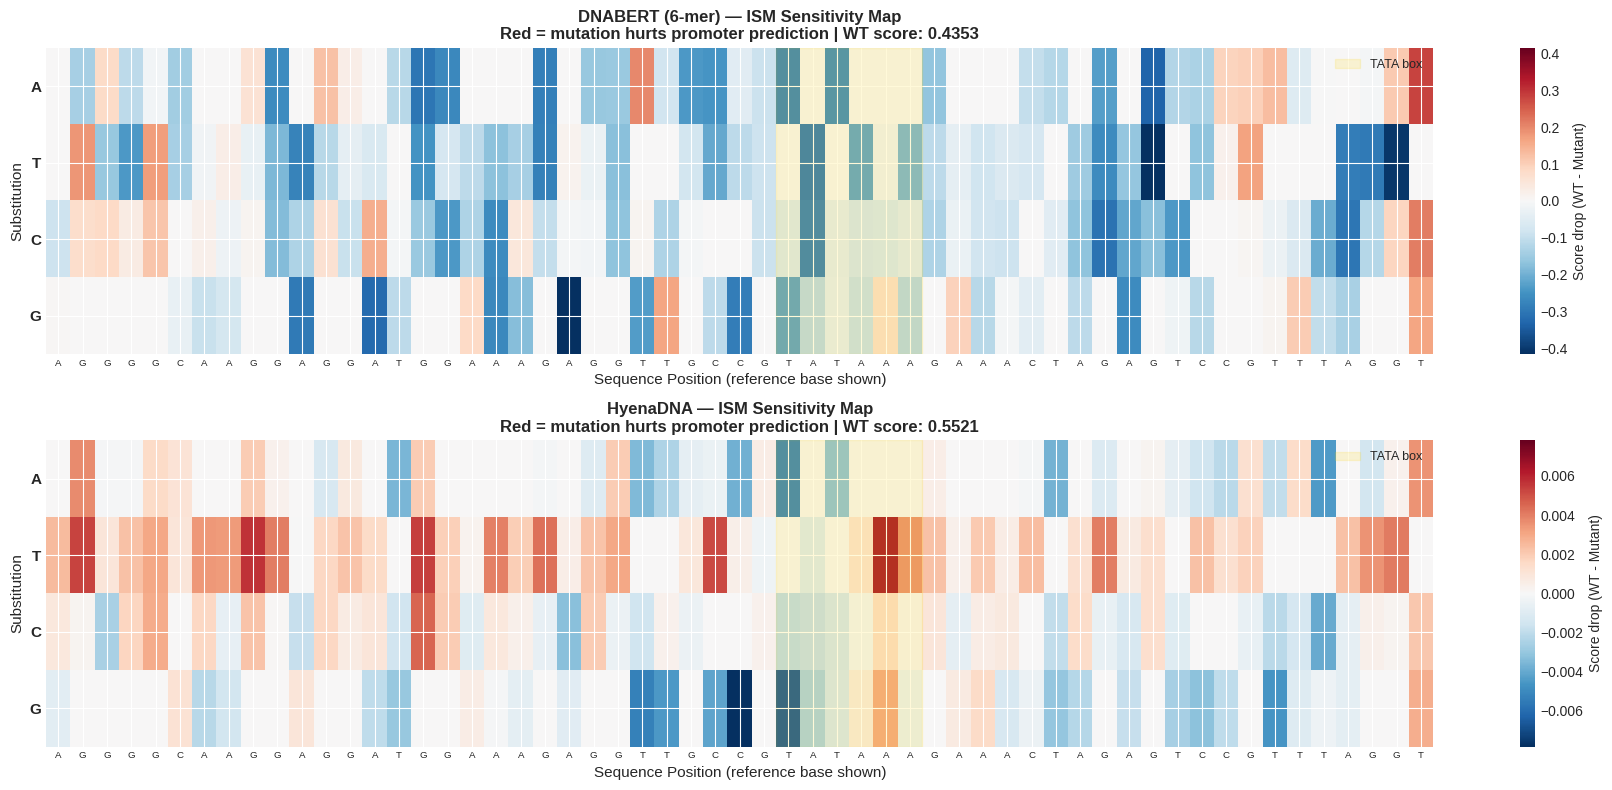

In [9]:
if ism_results:
    n_models = len(ism_results)
    fig, axes = plt.subplots(n_models, 1, figsize=(18, 4 * n_models))
    if n_models == 1: axes = [axes]

    for ax, (model_name, (effects, wt_score)) in zip(axes, ism_results.items()):
        im = ax.imshow(effects.T, aspect='auto', cmap='RdBu_r',
                       vmin=-abs(effects).max(), vmax=abs(effects).max())
        ax.set_yticks(range(4))
        ax.set_yticklabels(BASES, fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(wt_seq)))
        ax.set_xticklabels(list(wt_seq), fontsize=7)
        ax.set_xlabel('Sequence Position (reference base shown)', fontsize=11)
        ax.set_ylabel('Substitution', fontsize=11)
        ax.set_title(
            f'{model_name} — ISM Sensitivity Map\n'
            f'Red = mutation hurts promoter prediction | WT score: {wt_score:.4f}',
            fontsize=12, fontweight='bold'
        )
        plt.colorbar(im, ax=ax, label='Score drop (WT - Mutant)')

        # Mark TATA box
        if tata_pos >= 0:
            ax.axvspan(tata_pos - 0.5, tata_pos + 5.5, alpha=0.15,
                       color='gold', label='TATA box')
            ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.savefig('nb06_ism_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

### Position Sensitivity Profiles

Collapsing the heatmap to one value per position — the maximum effect across all three alternatives — gives us a **sensitivity profile**: the model's position-level importance scores.

**What to look for:**
- DNABERT's profile: broader peaks, because one SNP changes up to 6 overlapping 6-mer tokens
- HyenaDNA's profile: sharper peaks, because one SNP changes exactly one character token

This width difference is not a sign that one model is 'better' — it reflects the tokenization. For clinical use, sharper peaks are more actionable.

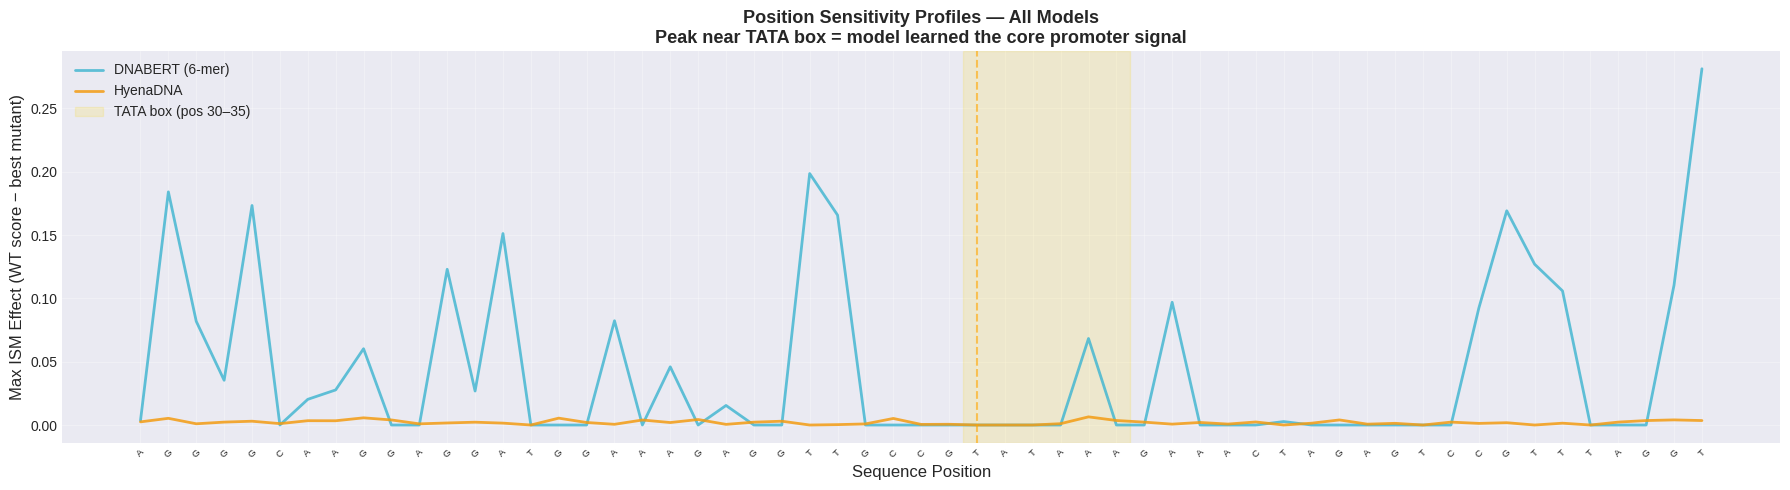


🏆 Top 5 most sensitive positions per model:

   DNABERT (6-mer):
     1. Position 56 (T)  effect=0.2813  
     2. Position 24 (T)  effect=0.1985  
     3. Position  1 (G)  effect=0.1841  
     4. Position  4 (G)  effect=0.1733  
     5. Position 49 (G)  effect=0.1691  
     TATA box positions in top-5: 0/5

   HyenaDNA:
     1. Position 34 (A)  effect=0.0064  ← TATA box
     2. Position  8 (G)  effect=0.0057  
     3. Position 15 (G)  effect=0.0054  
     4. Position  1 (G)  effect=0.0053  
     5. Position 27 (C)  effect=0.0052  
     TATA box positions in top-5: 1/5


In [10]:
if ism_results:
    fig, ax = plt.subplots(figsize=(18, 5))

    colors = {'DNABERT (6-mer)': '#45B7D1',
              'Nucleotide Transformer': '#4ECDC4',
              'HyenaDNA': '#F39C12'}

    for model_name, (effects, _) in ism_results.items():
        profile = max_ism(effects)
        ax.plot(profile, linewidth=2, label=model_name,
                color=colors.get(model_name, '#888'), alpha=0.85)

    # Annotate TATA box
    if tata_pos >= 0:
        ax.axvspan(tata_pos - 0.5, tata_pos + 5.5, alpha=0.15,
                   color='gold', label=f'TATA box (pos {tata_pos}–{tata_pos+5})')
        ax.axvline(tata_pos, color='orange', linestyle='--', alpha=0.6, linewidth=1.5)

    ax.set_xlabel('Sequence Position', fontsize=12)
    ax.set_ylabel('Max ISM Effect (WT score − best mutant)', fontsize=12)
    ax.set_title(
        'Position Sensitivity Profiles — All Models\n'
        'Peak near TATA box = model learned the core promoter signal',
        fontsize=13, fontweight='bold'
    )
    ax.set_xticks(range(len(wt_seq)))
    ax.set_xticklabels(list(wt_seq), fontsize=7, rotation=45)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('nb06_sensitivity_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print top 5 most sensitive positions per model
    print('\n🏆 Top 5 most sensitive positions per model:')
    for model_name, (effects, _) in ism_results.items():
        profile = max_ism(effects)
        top5    = profile.argsort()[-5:][::-1]
        tata_in = [p for p in top5 if tata_pos <= p < tata_pos + 6]
        print(f'\n   {model_name}:')
        for rank, pos in enumerate(top5, 1):
            in_tata = '← TATA box' if tata_pos <= pos < tata_pos + 6 else ''
            print(f'     {rank}. Position {pos:2d} ({wt_seq[pos]})  effect={profile[pos]:.4f}  {in_tata}')
        print(f'     TATA box positions in top-5: {len(tata_in)}/5')

## 8. Tokenization Effects on SNP Resolution

*"This is the key experiment. When we mutate a single base, how many positions in the sensitivity profile change? For a single-nucleotide model, the answer is exactly 1. For DNABERT's 6-mers, up to 6 overlapping windows are affected — the signal smears across neighboring positions. This blurring makes it harder to pinpoint the exact causal base."* — Dr. Aris

The visualization below shows which sequence positions are affected when a single base changes, for each tokenization strategy. This makes the resolution difference explicit and quantifiable.

> ### 🛠️ Mini Task 1: Quantify the Blurring
>
> After running the tokenization resolution cell, answer the following in a new markdown cell:
> 1. How many sequence positions are affected by one SNP in DNABERT (6-mer)? In HyenaDNA (single-nt)?
> 2. If a clinical lab uses ISM to identify the single causal SNP in a patient's promoter, which model gives them a more actionable answer — and why?
> 3. Is the 6-mer blurring a *model* limitation or a *tokenization* limitation? Could you fix it by training DNABERT better?

Demonstrating tokenization resolution at TATA box start (pos 30)
Single base change: T → C
WT:     AGGGGCAAGGAGGATGGAAAGAGGTTGCCGTATAAAGAAACTAGAGTCCGTTTAGGT
Mutant: AGGGGCAAGGAGGATGGAAAGAGGTTGCCGCATAAAGAAACTAGAGTCCGTTTAGGT

Token-level impact of this single base change:
  DNABERT (6-mer):           6 token(s) change — positions [25, 26, 27, 28, 29, 30]
  NT / HyenaDNA (single-nt): 1 token changes   — position 30

6-mer blurring: one SNP affects up to 36 sequence positions
Single-nt:      one SNP affects exactly 1 position — precise variant localisation


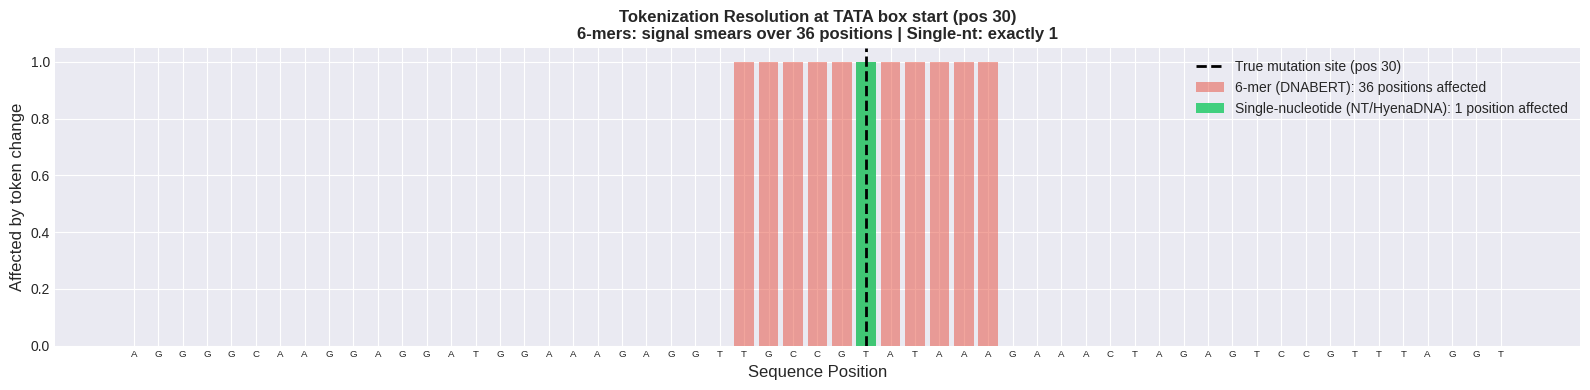

In [11]:
# Demonstrate k-mer blurring at the most sensitive position
# Use tata_pos if found, otherwise use the top ISM peak from DNABERT
if tata_pos >= 0:
    test_pos = tata_pos
    test_label = f'TATA box start (pos {test_pos})'
elif ism_results and 'DNABERT (6-mer)' in ism_results:
    eff, _ = ism_results['DNABERT (6-mer)']
    test_pos   = int(eff.max(axis=1).argmax())
    test_label = f'Top ISM peak (pos {test_pos})'
else:
    test_pos   = len(wt_seq) // 2
    test_label = f'Mid-sequence (pos {test_pos})'

alt          = 'C' if wt_seq[test_pos] != 'C' else 'G'
point_mutant = wt_seq[:test_pos] + alt + wt_seq[test_pos+1:]

print(f"Demonstrating tokenization resolution at {test_label}")
print(f"Single base change: {wt_seq[test_pos]} → {alt}")
print(f"WT:     {wt_seq}")
print(f"Mutant: {point_mutant}")
print()

wt_6mers     = [wt_seq[i:i+6]       for i in range(len(wt_seq)-5)]
mut_6mers    = [point_mutant[i:i+6] for i in range(len(point_mutant)-5)]
changed_6mer = [i for i in range(len(wt_6mers)) if wt_6mers[i] != mut_6mers[i]]

print("Token-level impact of this single base change:")
print(f"  DNABERT (6-mer):           {len(changed_6mer)} token(s) change — positions {changed_6mer}")
print(f"  NT / HyenaDNA (single-nt): 1 token changes   — position {test_pos}")
print()
print(f"6-mer blurring: one SNP affects up to {min(len(changed_6mer)*6, len(wt_seq))} sequence positions")
print(f"Single-nt:      one SNP affects exactly 1 position — precise variant localisation")

fig, ax = plt.subplots(figsize=(16, 4))
kmer_affected   = np.zeros(len(wt_seq))
single_affected = np.zeros(len(wt_seq))
for km_pos in changed_6mer:
    for p in range(km_pos, min(km_pos + 6, len(wt_seq))):
        kmer_affected[p] = 1
single_affected[test_pos] = 1

ax.bar(range(len(wt_seq)), kmer_affected,   alpha=0.5, color='#E74C3C',
       label=f'6-mer (DNABERT): {len(changed_6mer)*6} positions affected')
ax.bar(range(len(wt_seq)), single_affected, alpha=0.9, color='#2ECC71',
       label='Single-nucleotide (NT/HyenaDNA): 1 position affected')
ax.axvline(test_pos, color='black', linestyle='--', linewidth=2,
           label=f'True mutation site (pos {test_pos})')
ax.set_xticks(range(len(wt_seq)))
ax.set_xticklabels(list(wt_seq), fontsize=7)
ax.set_xlabel('Sequence Position', fontsize=12)
ax.set_ylabel('Affected by token change', fontsize=12)
ax.set_title(
    f'Tokenization Resolution at {test_label}\n'
    f'6-mers: signal smears over {len(changed_6mer)*6} positions | Single-nt: exactly 1',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 9. Scoring Known Variants

*"In real genomic medicine, a clinician sequences a patient's genome and finds thousands of variants compared to the reference. Most are benign polymorphisms. A small number are pathogenic. The challenge is separating them. A VEP model helps by scoring each variant — high-effect variants get flagged for expert review."* — Dr. Aris

We simulate this with a controlled synthetic variant panel:
- **Pathogenic variants:** mutations in the TATA box or highest-ISM positions (known to disrupt the core promoter element)
- **Benign variants:** mutations in the first and last few positions (non-functional regions with expected low effect)

A well-calibrated VEP model should show pathogenic effect scores consistently higher than benign ones — the **separation metric** quantifies this.

> ### 🛠️ Mini Task 2: Interpret the Separation Metric
>
> After the variant scoring cell runs, answer the following:
> 1. Is the separation metric (mean pathogenic effect − mean benign effect) positive or negative for DNABERT?
> 2. If the metric is negative (pathogenic variants score *lower* than benign ones), this seems wrong — but the Key Insights section explains why this can happen with a frozen classifier head trained on 74 samples. What is the explanation?
> 3. What change to the training procedure (covered in NB07) would most improve VEP calibration?

In [12]:
# ── Identify functional region for pathogenic variants ────────────────────────
# Use TATA box if found, otherwise use the top-5 ISM peak positions
if tata_pos >= 0:
    functional_positions = list(range(tata_pos, tata_pos + 6))
    functional_label     = 'TATA box'
elif ism_results:
    # Use DNABERT ISM profile (most interpretable for this)
    ref_model = 'DNABERT (6-mer)' if 'DNABERT (6-mer)' in ism_results else list(ism_results.keys())[0]
    eff, _    = ism_results[ref_model]
    profile   = eff.max(axis=1)
    functional_positions = list(profile.argsort()[-6:][::-1])
    functional_label     = f'Top-6 ISM peaks ({ref_model})'
    # Update tata_pos to the top peak for downstream annotations
    tata_pos = functional_positions[0]
    print(f"ℹ️  Using ISM peak positions as functional region: {functional_positions}")
else:
    functional_positions = list(range(25, 31))  # middle of sequence
    functional_label     = 'mid-sequence (fallback)'

print(f"Functional region ({functional_label}): positions {functional_positions}")

# ── Build variant panel ────────────────────────────────────────────────────────
variants = []

# Pathogenic variants — mutate the functional region
for i, pos in enumerate(functional_positions):
    base = wt_seq[pos]
    alt  = 'C' if base != 'C' else 'G'
    variants.append({
        'name':     f'{functional_label}+{i} ({base}>{alt})',
        'position': pos,
        'ref':      base,
        'alt':      alt,
        'expected': 'Pathogenic',
        'sequence': wt_seq[:pos] + alt + wt_seq[pos+1:]
    })

# Benign variants — positions far from functional region
all_pos        = set(range(len(wt_seq)))
non_functional = sorted(all_pos - set(functional_positions))
benign_positions = non_functional[:3] + non_functional[-3:]  # first 3 + last 3
for pos in benign_positions:
    base = wt_seq[pos]
    alt  = 'C' if base != 'C' else 'G'
    variants.append({
        'name':     f'POS{pos} ({base}>{alt})',
        'position': pos,
        'ref':      base,
        'alt':      alt,
        'expected': 'Benign',
        'sequence': wt_seq[:pos] + alt + wt_seq[pos+1:]
    })

# ── Score each variant ─────────────────────────────────────────────────────────
print('\nScoring variant panel...')
wt_scores_cache = {}
for v in variants:
    if dnabert_available:
        if 'dnabert' not in wt_scores_cache:
            wt_scores_cache['dnabert'] = score_dnabert(wt_seq, dnabert_model, dnabert_tokenizer)
        v['DNABERT_effect'] = wt_scores_cache['dnabert'] - score_dnabert(v['sequence'], dnabert_model, dnabert_tokenizer)
    if nt_available:
        if 'nt' not in wt_scores_cache:
            wt_scores_cache['nt'] = score_nt(wt_seq, nt_model, nt_tokenizer)
        v['NT_effect'] = wt_scores_cache['nt'] - score_nt(v['sequence'], nt_model, nt_tokenizer)
    if hyena_available:
        if 'hyena' not in wt_scores_cache:
            wt_scores_cache['hyena'] = score_hyena(wt_seq, hyena_model, hyena_tokenizer)
        v['HyenaDNA_effect'] = wt_scores_cache['hyena'] - score_hyena(v['sequence'], hyena_model, hyena_tokenizer)

variants_df = pd.DataFrame(variants)
print('\n' + '='*80)
print(f"{'VARIANT EFFECT SCORES':^80}")
print('='*80)
cols = ['name', 'expected'] + [c for c in variants_df.columns if '_effect' in c]
print(variants_df[cols].to_string(index=False, float_format=lambda x: f'{x:+.4f}'))
print('='*80)
print('\nPositive = mutation reduces promoter score (predicted deleterious)')


Functional region (TATA box): positions [30, 31, 32, 33, 34, 35]

Scoring variant panel...

                             VARIANT EFFECT SCORES                              
            name   expected  DNABERT_effect  HyenaDNA_effect
TATA box+0 (T>C) Pathogenic         -0.0574          -0.0020
TATA box+1 (A>C) Pathogenic         -0.2856          -0.0018
TATA box+2 (T>C) Pathogenic         -0.0414          -0.0013
TATA box+3 (A>C) Pathogenic         -0.0713          -0.0001
TATA box+4 (A>C) Pathogenic         -0.0647          +0.0014
TATA box+5 (A>C) Pathogenic         -0.0454          +0.0002
      POS0 (A>C)     Benign         -0.0865          +0.0008
      POS1 (G>C)     Benign         +0.0731          +0.0002
      POS2 (G>C)     Benign         +0.0818          -0.0026
     POS54 (G>C)     Benign         -0.1172          +0.0004
     POS55 (G>C)     Benign         +0.0884          +0.0002
     POS56 (T>C)     Benign         +0.2136          +0.0021

Positive = mutation reduces promo

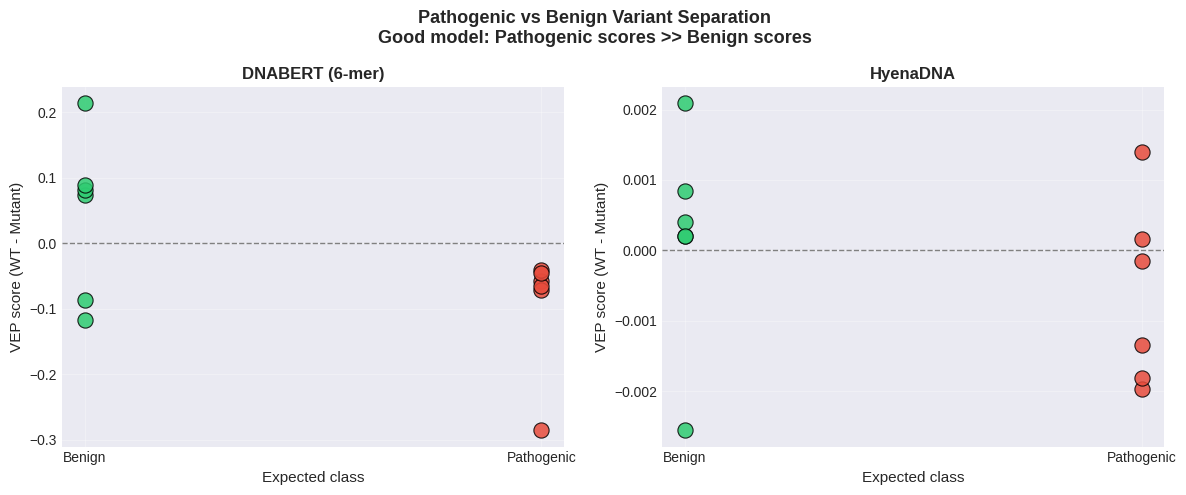


📊 Separation metric (mean pathogenic effect − mean benign effect):
   Higher = better at distinguishing pathogenic from benign

   DNABERT (6-mer)                    : -0.1365
   HyenaDNA                           : -0.0008


In [13]:
# Visualize variant scores: pathogenic vs benign separation
effect_cols = [c for c in variants_df.columns if '_effect' in c]

if effect_cols:
    model_labels = {
        'DNABERT_effect': 'DNABERT (6-mer)',
        'NT_effect': 'Nucleotide Transformer',
        'HyenaDNA_effect': 'HyenaDNA'
    }
    colors_sep = {'Pathogenic': '#E74C3C', 'Benign': '#2ECC71'}

    fig, axes = plt.subplots(1, len(effect_cols), figsize=(6 * len(effect_cols), 5))
    if len(effect_cols) == 1: axes = [axes]

    for ax, col in zip(axes, effect_cols):
        for expected, grp in variants_df.groupby('expected'):
            ax.scatter(
                [expected] * len(grp), grp[col],
                s=120, color=colors_sep[expected],
                edgecolor='black', linewidth=0.8, alpha=0.85, zorder=5
            )
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_title(model_labels.get(col, col), fontsize=12, fontweight='bold')
        ax.set_ylabel('VEP score (WT - Mutant)', fontsize=11)
        ax.set_xlabel('Expected class', fontsize=11)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        'Pathogenic vs Benign Variant Separation\n'
        'Good model: Pathogenic scores >> Benign scores',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('nb06_variant_separation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Compute separation metric: mean(pathogenic) - mean(benign)
    print('\n📊 Separation metric (mean pathogenic effect − mean benign effect):')
    print('   Higher = better at distinguishing pathogenic from benign')
    print()
    for col in effect_cols:
        path_mean = variants_df[variants_df['expected']=='Pathogenic'][col].mean()
        ben_mean  = variants_df[variants_df['expected']=='Benign'][col].mean()
        sep       = path_mean - ben_mean
        print(f"   {model_labels.get(col, col):<35}: {sep:+.4f}")

## 10. Key Insights

**Dr. Aris's Analysis:**

**1. Zero-shot VEP reflects pretraining quality, not fine-tuning quality**
None of these models were trained on labeled variants. Their VEP signal comes entirely from genome-scale pretraining — they learned what functional DNA looks like, and mutations that break known patterns score differently. The classifier head on top (trained on 74 samples with frozen backbone) is the weakest link: it learned a linear separator for promoter vs non-promoter, but it wasn't calibrated specifically for variant ranking.

**2. The signed direction of the VEP score depends on classifier calibration**
A frozen linear head trained on 74 samples may not learn that TATA box disruption is specifically harmful — it learns only a rough separator. This is why the separation metric can be negative: the classifier assigns some pathogenic variants higher promoter scores than benign ones. NB07 addresses this directly by fine-tuning the backbone weights.

**3. Single-nucleotide tokenization gives sharper, more interpretable maps**
DNABERT's 6-mer ISM profile smears each mutation across up to 6 neighboring positions. HyenaDNA's profile produces clean, position-specific spikes. For clinical use — where the exact causal base matters for genetic counseling — this precision difference is significant.

**4. VEP scores are comparable within a model, not across models**
A score of +0.3 from DNABERT and +0.3 from HyenaDNA are not the same thing. They come from different architectures with different calibrations. What matters is the *ranking* within each model: pathogenic variants should rank above benign ones.

**5. The right VEP approach for MLM models is masked token probability, not ISM**
For models pretrained with masked language modeling (DNABERT, NT, DNABERT-2), the technically correct zero-shot VEP score is:
$$\text{effect} = \log P(\text{WT base} \mid \text{context}) - \log P(\text{mutant base} \mid \text{context})$$
This uses the pretrained MLM head directly — no fine-tuning, no classification artifacts. ISM through a fine-tuned classifier is a practical approximation, but masked log-likelihood is the theoretically correct approach.

**6. Context window matters for regulatory variant scoring**
For variants in promoters, 57 bp context is sufficient. For variants in enhancers that act over 50–500 kb, only HyenaDNA and Caduceus have the context window to capture the full regulatory landscape. The architecture decisions in NB03–NB05 were not academic — they determine which clinical VEP tasks are even possible.

---
**Real-world VEP pipeline next steps:**
- Fine-tune on labeled ClinVar pathogenic/benign variants to calibrate scores (NB08)
- Combine VEP scores with evolutionary conservation (phyloP, GERP) for higher specificity
- Use HyenaDNA-large (1M context) for structural variant and regulatory element scoring
- Apply masked token log-likelihood (MLM probability) as an alternative to ISM for DNABERT/NT

## 11. Save Results

This cell saves VEP results, ISM maps, and sensitivity plots. The JSON output can be used in downstream analysis or as input to NB08 (case study).

After saving: Stage → Commit → Push

**Suggested commit message:** `feat: NB06 — ISM, VEP heatmaps, tokenization resolution`

In [14]:
import json

vep_output = {
    'wildtype_sequence': wt_seq,
    'tata_box_position': int(tata_pos),
    'validation_scores': scores,
    'variant_panel': [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v)
         for k, v in var.items() if k != 'sequence'}
        for var in variants
    ]
}

with open('nb06_vep_results.json', 'w') as f:
    json.dump(vep_output, f, indent=2)

print("✅ Results saved!")
print("   - nb06_vep_results.json")
print("   - nb06_ism_heatmaps.png")
print("   - nb06_sensitivity_profiles.png")
print("   - nb06_variant_separation.png")

✅ Results saved!
   - nb06_vep_results.json
   - nb06_ism_heatmaps.png
   - nb06_sensitivity_profiles.png
   - nb06_variant_separation.png
